### Import Libraries

We import essential libraries for data manipulation, text processing, machine learning models, deep learning layers, evaluation metrics, and visualization.


In [1]:
# ===================== Import Libraries =====================

# Basic data manipulation libraries
import pandas as pd            # for dataframes and data manipulation
import numpy as np             # for numerical operations

# Text preprocessing libraries
import re                     # for regular expressions
import string                 # for string operations
import nltk                   # for natural language processing tasks
from nltk.corpus import stopwords    # for stopword removal
from nltk.stem import WordNetLemmatizer  # for lemmatization

# Machine learning models
from sklearn.linear_model import LogisticRegression    # logistic regression
from sklearn.ensemble import RandomForestClassifier    # random forest
from sklearn.svm import SVC                           # support vector machine
from sklearn.naive_bayes import MultinomialNB         # naive bayes
from xgboost import XGBClassifier                    # XGBoost
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier  # boosting models

# Deep learning (TensorFlow / Keras) libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential               # sequential model
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout  # neural network layers
from tensorflow.keras.preprocessing.text import Tokenizer    # tokenizer for text
from tensorflow.keras.preprocessing.sequence import pad_sequences  # sequence padding

# Feature extraction methods
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer  # bag of words, TF-IDF

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Model selection and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

# Visualization libraries
import matplotlib.pyplot as plt    # for plotting
import seaborn as sns             # for enhanced plots

# Suppress warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')


In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

### Load Dataset

We load the Amazon product review dataset containing review texts and their sentiment labels (positive/negative).


In [3]:
df = pd.read_csv('/content/amazon (1).csv')

In [4]:
df.head(20)

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1
5,This is a very entertaining game! You don't h...,1
6,this is awesome and you don't need wi ti to pl...,1
7,this is awesome I bet no one even reads the re...,1
8,This is basicly the free version but with ads....,1
9,this is by far the best free app that is avail...,1


In [5]:
df.shape


(20000, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   reviewText  20000 non-null  object
 1   Positive    20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


In [7]:
df.isnull().sum()


,0
reviewText,0
Positive,0


In [8]:

df.tail()


,reviewText,Positive
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1
19999,This game is a rip off. Here is a list of thin...,0


### Check Class Distribution

We plot the distribution of positive and negative reviews to check for class imbalance.


In [9]:
df['Positive'].value_counts()


,count
Positive,
1,15233
0,4767


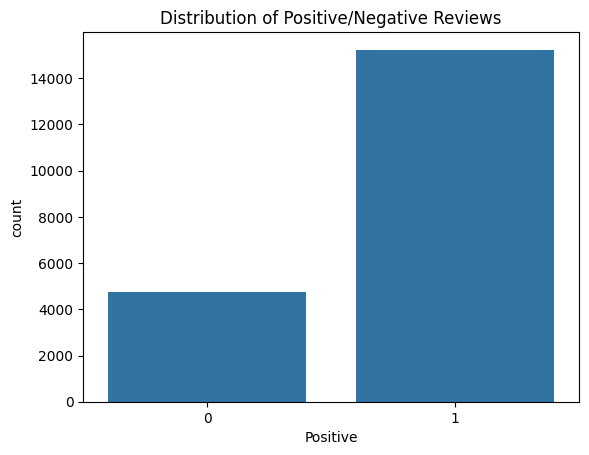

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Positive', data=df)
plt.title('Distribution of Positive/Negative Reviews')
plt.show()


In [11]:
df['review_length'] = df['reviewText'].apply(len)
df['review_length'].describe()


,review_length
count,20000.000000
mean,175.793850
std,58.966619
min,3.000000
25%,123.000000
50%,164.000000
75%,254.000000
max,254.000000


In [12]:
df.head()

,reviewText,Positive,review_length
0,This is a one of the best apps acording to a b...,1,129
1,This is a pretty good version of the game for ...,1,129
2,this is a really cool game. there are a bunch ...,1,96
3,"This is a silly game and can be frustrating, b...",1,105
4,This is a terrific game on any pad. Hrs of fun...,1,117


### Add Review Length and Word Count Features

We compute additional features — the length of each review and the number of words — to explore their distributions and potential correlation with sentiment.


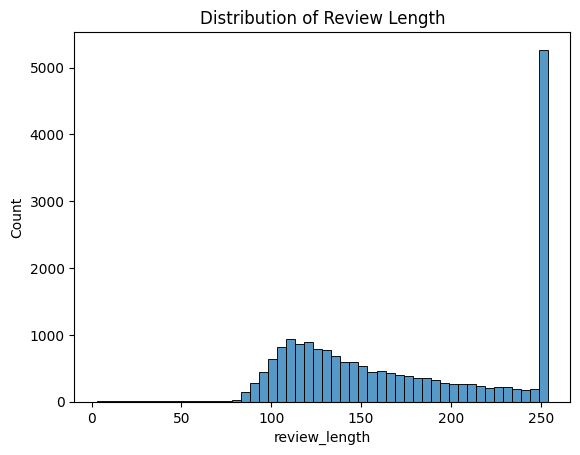

In [13]:
sns.histplot(df['review_length'], bins=50)
plt.title('Distribution of Review Length')
plt.show()


In [14]:
df['word_count'] = df['reviewText'].apply(lambda x: len(str(x).split()))
df['word_count'].describe()


,word_count
count,20000.000000
mean,33.941450
std,11.217532
min,1.000000
25%,24.000000
50%,31.000000
75%,45.000000
max,61.000000


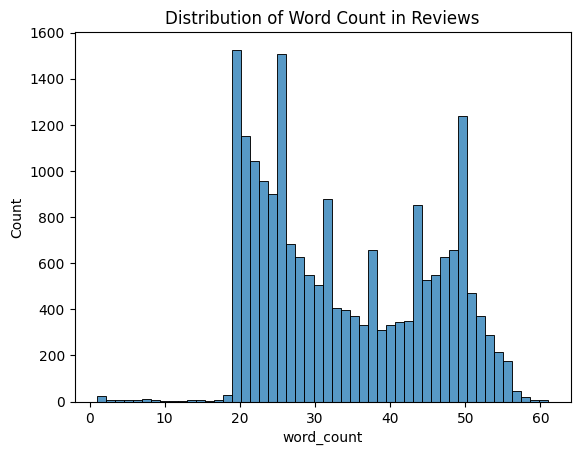

In [15]:
sns.histplot(df['word_count'], bins=50)
plt.title('Distribution of Word Count in Reviews')
plt.show()


### Word Frequency Analysis

We analyze the most common words across all reviews after removing stopwords to understand key patterns in the text data.


In [16]:
# ===================== Word Frequency Analysis =====================

# Import Counter to count word frequencies
from collections import Counter

# Import nltk and stopwords
import nltk
from nltk.corpus import stopwords

# Download the NLTK stopwords list
nltk.download('stopwords')

# Create a set of English stopwords
stop_words = set(stopwords.words('english'))

# Combine all review texts into a single string, convert to lowercase, and split into words
all_words = ' '.join(df['reviewText']).lower().split()

# Filter words: keep only alphabetic words and remove stopwords
filtered_words = [word for word in all_words if word.isalpha() and word not in stop_words]

# Get the 20 most common words and their frequencies
common_words = Counter(filtered_words).most_common(20)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


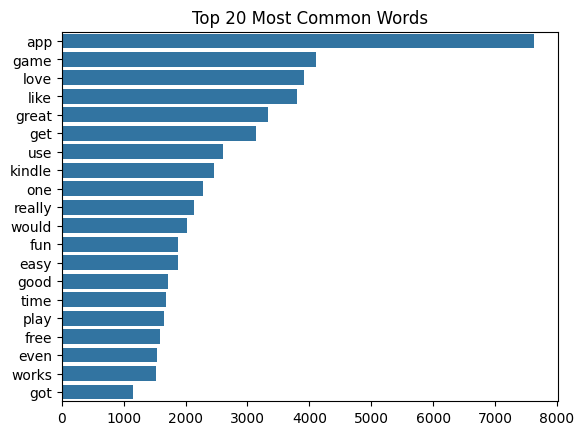

In [17]:
words, counts = zip(*common_words)
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Most Common Words')
plt.show()


### Analyze Review Length by Sentiment

We compare average review length and word count between positive and negative reviews to explore linguistic differences.


In [18]:
df.groupby('Positive')['review_length'].mean()
df.groupby('Positive')['word_count'].mean()


,word_count
Positive,
0,33.254248
1,34.156502


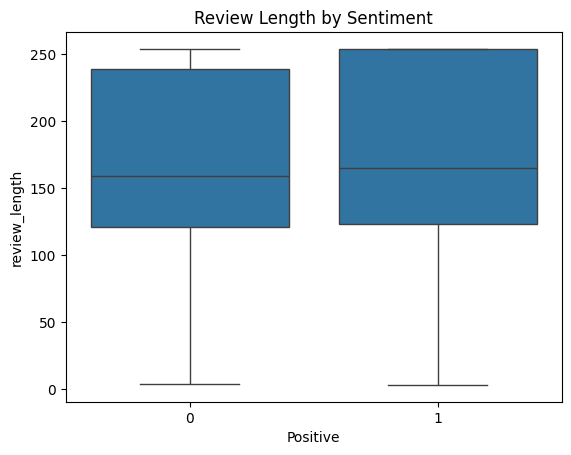

In [19]:
sns.boxplot(x='Positive', y='review_length', data=df)
plt.title('Review Length by Sentiment')
plt.show()


In [20]:
df.duplicated().sum()


np.int64(0)

In [21]:
df['clean_text'] = df['reviewText'].str.lower()


In [22]:
df.head()

,reviewText,Positive,review_length,word_count,clean_text
0,This is a one of the best apps acording to a b...,1,129,28,this is a one of the best apps acording to a b...
1,This is a pretty good version of the game for ...,1,129,27,this is a pretty good version of the game for ...
2,this is a really cool game. there are a bunch ...,1,96,20,this is a really cool game. there are a bunch ...
3,"This is a silly game and can be frustrating, b...",1,105,21,"this is a silly game and can be frustrating, b..."
4,This is a terrific game on any pad. Hrs of fun...,1,117,22,this is a terrific game on any pad. hrs of fun...


### Data Cleaning

We clean the text by lowercasing, removing HTML tags, punctuation, numbers, and stopwords, preparing it for modeling.


In [23]:
import re
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()  # lowercase
    text = re.sub(r'<.*?>', '', text)  # remove HTML tags
    text = re.sub(r'[^\s\w]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = re.sub(r'\s+', ' ', text)  # remove extra spaces
    text = ' '.join([word for word in text.split() if word not in stop_words])  # remove stopwords
    return text

df['clean_review'] = df['reviewText'].apply(clean_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Encode Sentiment Labels

We convert the `Positive` label from categorical to numeric format using LabelEncoder.


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Positive'] = le.fit_transform(df['Positive'])


In [25]:
df.head()

,reviewText,Positive,review_length,word_count,clean_text,clean_review
0,This is a one of the best apps acording to a b...,1,129,28,this is a one of the best apps acording to a b...,one best apps acording bunch people agree bomb...
1,This is a pretty good version of the game for ...,1,129,27,this is a pretty good version of the game for ...,pretty good version game free lots different l...
2,this is a really cool game. there are a bunch ...,1,96,20,this is a really cool game. there are a bunch ...,really cool game bunch levels find golden eggs...
3,"This is a silly game and can be frustrating, b...",1,105,21,"this is a silly game and can be frustrating, b...",silly game frustrating lots fun definitely rec...
4,This is a terrific game on any pad. Hrs of fun...,1,117,22,this is a terrific game on any pad. hrs of fun...,terrific game pad hrs fun grandkids love great...


### Apply Lemmatization

We lemmatize words to reduce them to their base form, improving the quality of the features.


In [26]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

df['clean_review'] = df['clean_review'].apply(lemmatize_text)


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [27]:
df[['reviewText', 'clean_review']].sample(5)


,reviewText,clean_review
15774,Because I have added so many apps in the Appst...,added many apps appstore quotapp dayquot neede...
9032,Task managers are pathetic and are based on th...,task manager pathetic based assumption phone d...
13024,This app is super sweet - it's a star map that...,app super sweet star map know direction youre ...
13349,I really LOVED this app. Very fun and interact...,really loved app fun interactive thinking gett...
4100,The app is fine. But it is being down voted by...,app fine voted moron never used amazon filter ...


In [28]:
df['Positive'].value_counts()


,count
Positive,
1,15233
0,4767


In [29]:
df.head()

,reviewText,Positive,review_length,word_count,clean_text,clean_review
0,This is a one of the best apps acording to a b...,1,129,28,this is a one of the best apps acording to a b...,one best apps acording bunch people agree bomb...
1,This is a pretty good version of the game for ...,1,129,27,this is a pretty good version of the game for ...,pretty good version game free lot different le...
2,this is a really cool game. there are a bunch ...,1,96,20,this is a really cool game. there are a bunch ...,really cool game bunch level find golden egg s...
3,"This is a silly game and can be frustrating, b...",1,105,21,"this is a silly game and can be frustrating, b...",silly game frustrating lot fun definitely reco...
4,This is a terrific game on any pad. Hrs of fun...,1,117,22,this is a terrific game on any pad. hrs of fun...,terrific game pad hr fun grandkids love great ...


### Apply Lemmatization

We lemmatize words to reduce them to their base form, improving the quality of the features.


In [30]:
# ===================== TF-IDF Vectorization =====================

# Import TfidfVectorizer to convert text data into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer with a maximum of 5000 features (most important words)
tfidf = TfidfVectorizer(max_features=5000)

# Transform the 'clean_review' column into a TF-IDF feature matrix (X)
X = tfidf.fit_transform(df['clean_review'])

# Set the target variable (y) as the 'Positive' column
y = df['Positive']


### Plot Class Distribution

We visualize the balance of positive and negative classes before and after applying SMOTE oversampling.


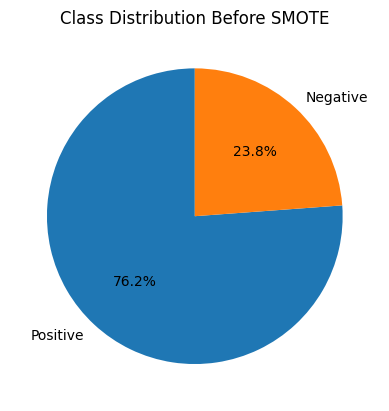

In [31]:
y.value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, labels=['Positive', 'Negative'])
plt.title('Class Distribution Before SMOTE')
plt.ylabel('')  # Remove y-axis label for clean look
plt.show()



### Train-Test Split

We split the dataset into training and testing sets to prepare for modeling and evaluation.


### Apply SMOTE for Class Balancing

We use SMOTE to oversample the minority class in the training data, improving the model's ability to handle imbalance.


In [32]:
# ===================== Train-Test Split =====================

# Split the feature matrix X and target y into training and testing sets
# Use stratified splitting to maintain the class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)

# ===================== Apply SMOTE =====================

# Import SMOTE from imblearn for oversampling the minority class
from imblearn.over_sampling import SMOTE

# Initialize the SMOTE object with a fixed random state for reproducibility
smote = SMOTE(random_state=42)

# Apply SMOTE only on the training data to balance the class distribution
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


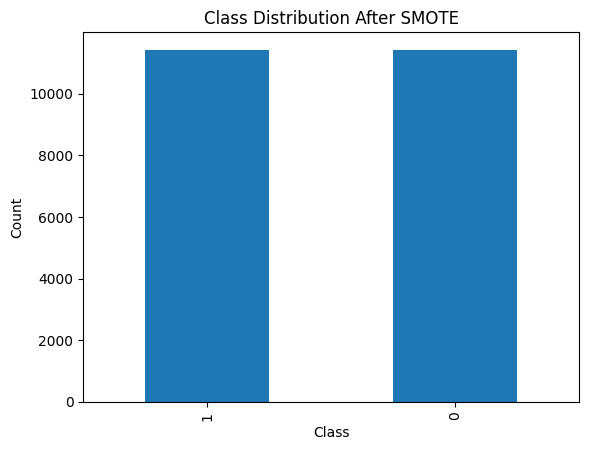

In [33]:
import pandas as pd

pd.Series(y_train_resampled).value_counts().plot(kind='bar')
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


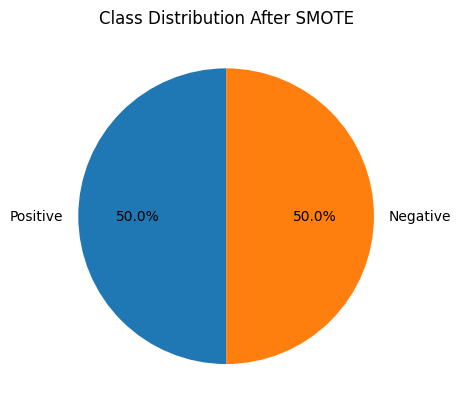

In [34]:
import pandas as pd

pd.Series(y_train_resampled).value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, labels=['Positive', 'Negative']
)
plt.title('Class Distribution After SMOTE')
plt.ylabel('')
plt.show()


### Train and Evaluate Machine Learning Models

We train multiple ML models (Logistic Regression, Random Forest, SVM, Naive Bayes, XGBoost), evaluate them with accuracy and classification reports, and visualize confusion matrices and ROC curves.



===== Model: Logistic Regression =====
Accuracy: 0.89025
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.65      0.74       953
           1       0.90      0.96      0.93      3047

    accuracy                           0.89      4000
   macro avg       0.88      0.81      0.83      4000
weighted avg       0.89      0.89      0.88      4000



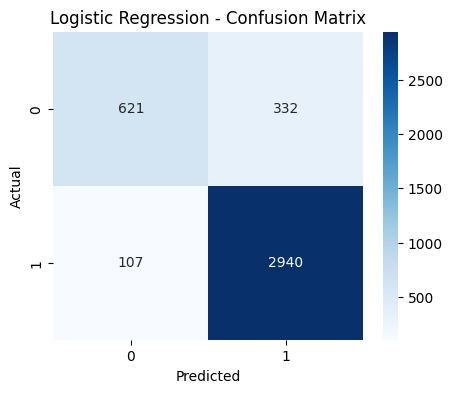

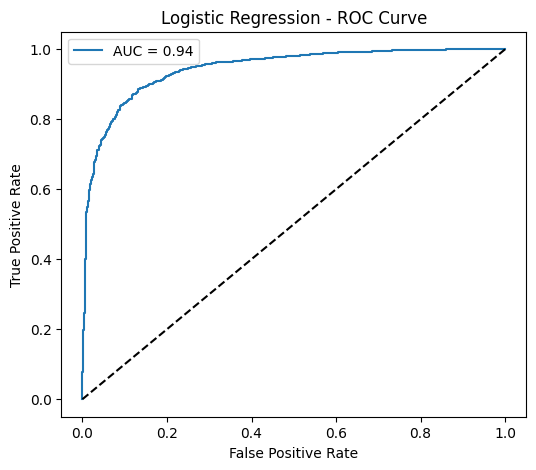


===== Model: Random Forest =====
Accuracy: 0.86475
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.56      0.66       953
           1       0.87      0.96      0.92      3047

    accuracy                           0.86      4000
   macro avg       0.84      0.76      0.79      4000
weighted avg       0.86      0.86      0.86      4000



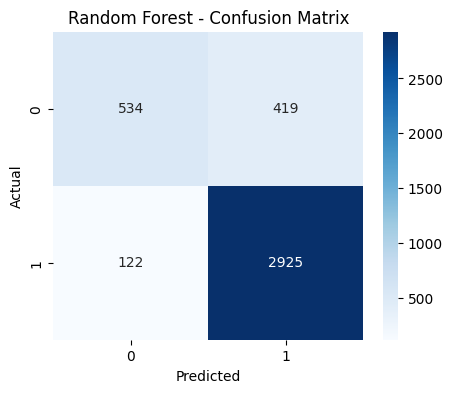

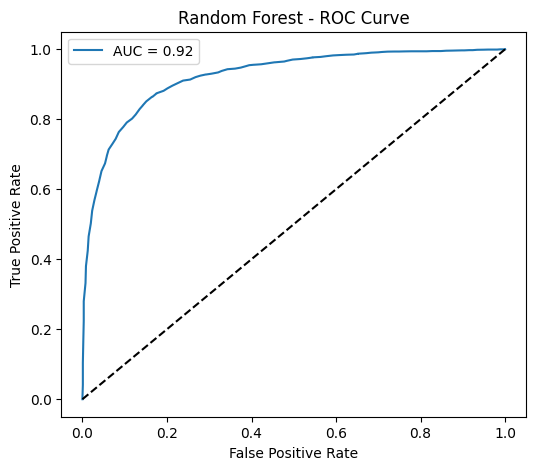


===== Model: SVM (Linear Kernel) =====
Accuracy: 0.89725
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77       953
           1       0.92      0.95      0.93      3047

    accuracy                           0.90      4000
   macro avg       0.87      0.84      0.85      4000
weighted avg       0.89      0.90      0.89      4000



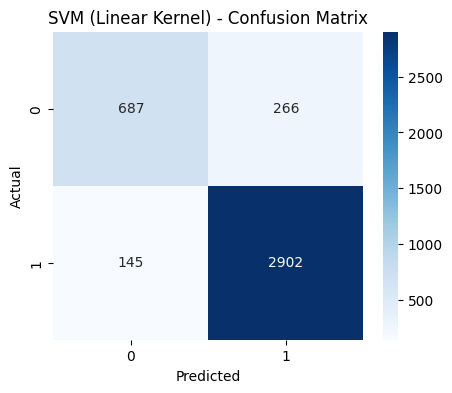

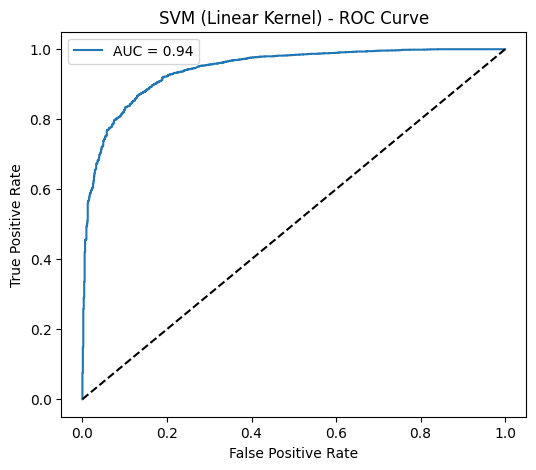


===== Model: Naive Bayes =====
Accuracy: 0.85525
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.45      0.60       953
           1       0.85      0.98      0.91      3047

    accuracy                           0.86      4000
   macro avg       0.87      0.72      0.75      4000
weighted avg       0.86      0.86      0.84      4000



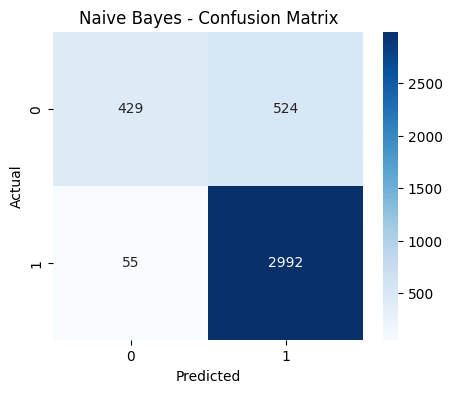

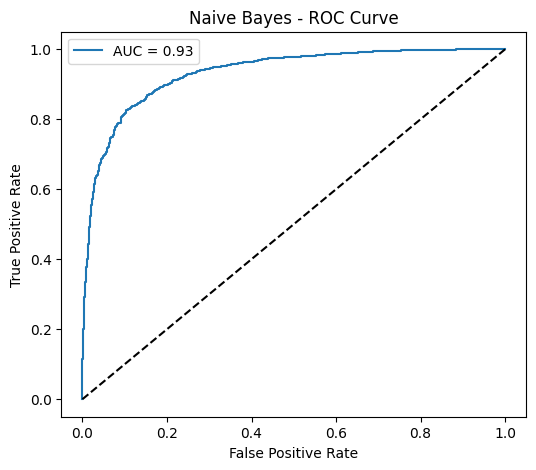


===== Model: XGBoost =====
Accuracy: 0.8725
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.59      0.69       953
           1       0.88      0.96      0.92      3047

    accuracy                           0.87      4000
   macro avg       0.85      0.78      0.80      4000
weighted avg       0.87      0.87      0.86      4000



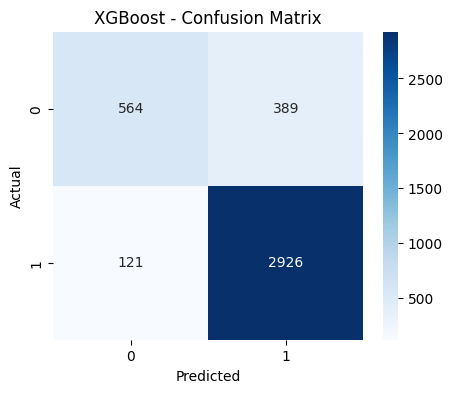

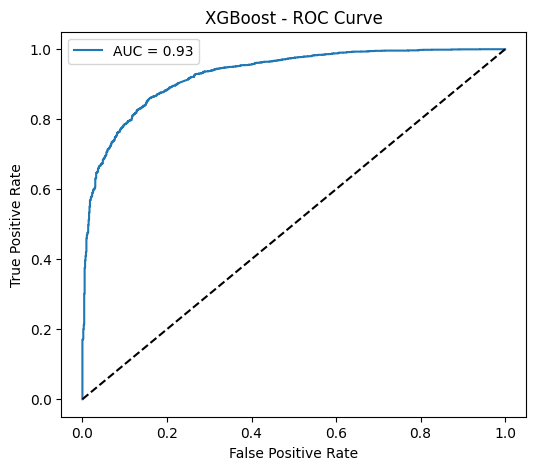

In [45]:
# ===================== 1. DATA SPLITTING =====================
from sklearn.metrics import roc_curve, auc



# Split the dataset into train and test sets for deep learning models (raw text)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_review'], df['Positive'], test_size=0.2, random_state=42, stratify=df['Positive']
)

# Create TF-IDF features for machine learning models
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_review'])

# Split the TF-IDF matrix into train and test sets for ML
X_train_ml, X_test_ml, _, _ = train_test_split(
    X_tfidf, df['Positive'], test_size=0.2, random_state=42, stratify=df['Positive']
)

# ===================== 2. MACHINE LEARNING MODELS =====================

# Define a dictionary of ML models to train and evaluate
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(),
    'SVM (Linear Kernel)': SVC(kernel='linear', probability=True),
    'Naive Bayes': MultinomialNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Loop over each model, train it, evaluate it, and plot metrics
for name, model in models.items():
    # Train the model
    model.fit(X_train_ml, y_train)

    # Make predictions
    y_pred = model.predict(X_test_ml)

    # Get predicted probabilities for ROC curve
    y_proba = model.predict_proba(X_test_ml)[:,1] if hasattr(model, 'predict_proba') else model.decision_function(X_test_ml)
    y_proba = (y_proba - y_proba.min()) / (y_proba.max() - y_proba.min())  # Scale to [0,1] if needed

    # Print evaluation metrics
    print(f"\n===== Model: {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Plot ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1],[0,1],'k--')  # Diagonal reference line
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name} - ROC Curve')
    plt.legend()
    plt.show()


### Prepare Data for Deep Learning Models

We tokenize and pad the review texts to prepare inputs for LSTM and GRU models.



===== Training Bidirectional LSTM =====
Epoch 1/15
500/500 - 57s - 115ms/step - accuracy: 0.8539 - loss: 0.3466 - val_accuracy: 0.8892 - val_loss: 0.2636
Epoch 2/15
500/500 - 83s - 165ms/step - accuracy: 0.9240 - loss: 0.1958 - val_accuracy: 0.8947 - val_loss: 0.2600
Epoch 3/15
500/500 - 81s - 161ms/step - accuracy: 0.9466 - loss: 0.1450 - val_accuracy: 0.8925 - val_loss: 0.2804
Epoch 4/15
500/500 - 51s - 103ms/step - accuracy: 0.9628 - loss: 0.1085 - val_accuracy: 0.8842 - val_loss: 0.3393
Epoch 5/15
500/500 - 84s - 168ms/step - accuracy: 0.9706 - loss: 0.0854 - val_accuracy: 0.8882 - val_loss: 0.3531
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step

===== Bidirectional LSTM Evaluation =====
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       953
           1       0.94      0.92      0.93      3047

    accuracy                           0.89      4000
   macro avg       0.85      0.86      0.86      4000
weighted avg       0.90      0.8

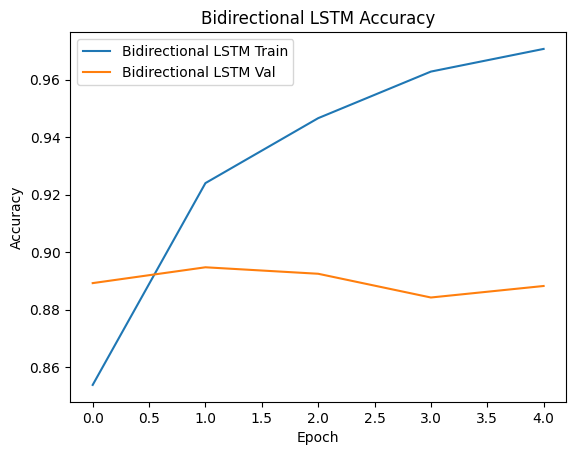

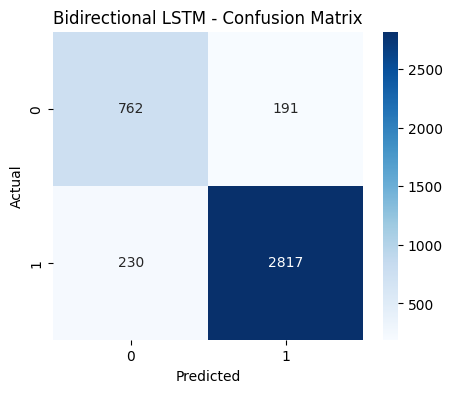

In [36]:
# Import necessary libraries
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ====================== Data Preparation ======================

# Initialize tokenizer with a vocabulary size of 10,000 and OOV token for unknown words
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')

# Fit tokenizer on training text
tokenizer.fit_on_texts(X_train_text)

# Convert text to integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences to have the same length
max_len = 100
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Set up early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# ====================== Model Training and Evaluation Function ======================

def train_dl_model(model_name, RNN_layer):
    # Define sequential model architecture
    model = Sequential([
        Embedding(input_dim=10000, output_dim=64, input_length=max_len),
        Bidirectional(RNN_layer),   # Use Bidirectional wrapper for LSTM or GRU
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(loss='binary_crossentropy', optimizer=Adam(0.001), metrics=['accuracy'])

    # Train the model
    print(f"\n===== Training {model_name} =====")
    history = model.fit(
        X_train_pad, y_train,
        epochs=15, batch_size=32,
        validation_data=(X_test_pad, y_test),
        callbacks=[early_stop],
        verbose=2
    )

    # Make predictions on the test set
    y_pred_prob = model.predict(X_test_pad)
    y_pred = (y_pred_prob > 0.5).astype('int32').flatten()

    # Print classification metrics
    print(f"\n===== {model_name} Evaluation =====")
    print(classification_report(y_test, y_pred))

    # Calculate and print confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # Plot accuracy over epochs
    plt.plot(history.history['accuracy'], label=f'{model_name} Train')
    plt.plot(history.history['val_accuracy'], label=f'{model_name} Val')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # Plot confusion matrix as heatmap
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# ====================== Run Bidirectional LSTM ======================

from tensorflow.keras.layers import LSTM as LSTM_layer
train_dl_model('Bidirectional LSTM', LSTM_layer(64))



===== Training Bidirectional GRU =====
Epoch 1/15
500/500 - 63s - 125ms/step - accuracy: 0.8499 - loss: 0.3595 - val_accuracy: 0.8790 - val_loss: 0.2813
Epoch 2/15
500/500 - 55s - 110ms/step - accuracy: 0.9156 - loss: 0.2137 - val_accuracy: 0.8885 - val_loss: 0.2675
Epoch 3/15
500/500 - 83s - 167ms/step - accuracy: 0.9439 - loss: 0.1536 - val_accuracy: 0.8925 - val_loss: 0.2872
Epoch 4/15
500/500 - 82s - 165ms/step - accuracy: 0.9606 - loss: 0.1117 - val_accuracy: 0.8873 - val_loss: 0.3071
Epoch 5/15
500/500 - 82s - 165ms/step - accuracy: 0.9746 - loss: 0.0799 - val_accuracy: 0.8880 - val_loss: 0.3541
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

===== Bidirectional GRU Evaluation =====
              precision    recall  f1-score   support

           0       0.82      0.68      0.74       953
           1       0.91      0.95      0.93      3047

    accuracy                           0.89      4000
   macro avg       0.86      0.82      0.84      4000
weighted avg       0.89      0.89 

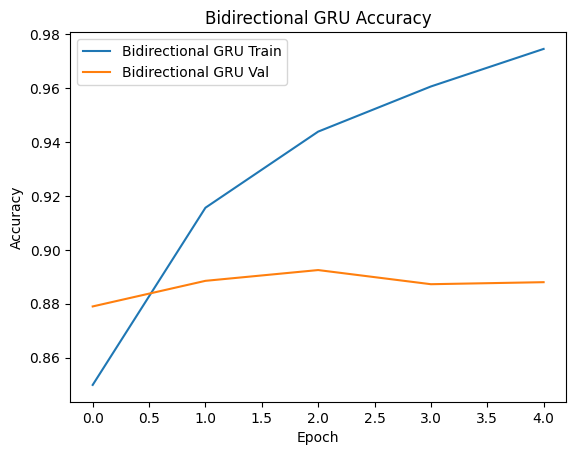

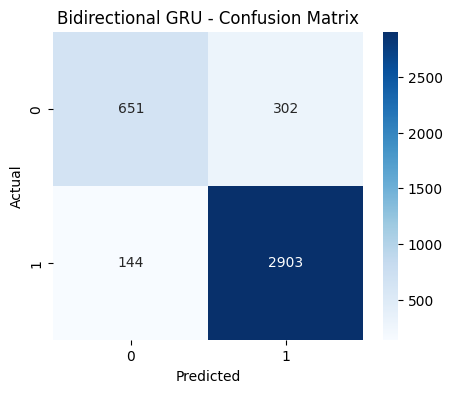

In [37]:
# Run GRU
from tensorflow.keras.layers import GRU as GRU_layer
train_dl_model('Bidirectional GRU', GRU_layer(64))

## **Ensembling 3 best ML Models**

In [38]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000)),
        ('rf', RandomForestClassifier()),
        ('svc', SVC(kernel='linear', probability=True))
    ],
    voting='soft'
)

voting_clf.fit(X_train_ml, y_train)
y_pred = voting_clf.predict(X_test_ml)

print("===== Voting Classifier Ensemble =====")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


===== Voting Classifier Ensemble =====
Accuracy: 0.89775
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       953
           1       0.91      0.96      0.93      3047

    accuracy                           0.90      4000
   macro avg       0.88      0.82      0.85      4000
weighted avg       0.90      0.90      0.89      4000

[[ 651  302]
 [ 107 2940]]


## Hyperparameter tuning

In [39]:
# lr = LogisticRegression(max_iter=1000)
# rf = RandomForestClassifier()
# svc = SVC(kernel='linear', probability=True)

# voting_clf = VotingClassifier(
#     estimators=[
#         ('lr', lr),
#         ('rf', rf),
#         ('svc', svc)
#     ],
#     voting='soft'
# )


# param_grid = {
#     'lr__C': [0.1, 1, 10],
#     'rf__n_estimators': [100, 200],
#     'rf__max_depth': [None, 10],
#     'svc__C': [0.1, 1, 10],
#     'voting': ['soft']
# }


# grid = GridSearchCV(voting_clf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
# grid.fit(X_train_ml, y_train)

# y_pred_tuned = grid.predict(X_test_ml)

# print("\n===== Tuned Voting Classifier Ensemble (GridSearchCV) =====")
# print("Best Parameters:", grid.best_params_)
# print("Best Cross-Validation Score:", grid.best_score_)
# print("Test Accuracy:", accuracy_score(y_test, y_pred_tuned))
# print(classification_report(y_test, y_pred_tuned))
# print(confusion_matrix(y_test, y_pred_tuned))


### Hyperparameter Tuning with Keras Tuner (LSTM Model)

In this step, we use **Keras Tuner** to perform hyperparameter optimization for our bidirectional LSTM sentiment classification model.

- We define a model-building function that allows tuning:
  - `embedding_dim` (32, 64, 128)
  - `lstm_units` (32–128)
  - `dropout` rate (0.2–0.5)
  - `learning_rate` (0.01, 0.001, 0.0001)

- We set up a `RandomSearch` tuner to explore 5 combinations of hyperparameters.
- We train models on the training set (`X_train_pad, y_train`) with validation on the test set.

After the search:
- We retrieve the **best model** from the tuner.
- We evaluate the tuned LSTM on the test set, print the classification report and confusion matrix, and visualize the confusion matrix as a heatmap.

This helps us identify the most effective LSTM configuration for our sentiment analysis task.


Reloading Tuner from lstm_tuner_dir/sentiment_lstm/tuner0.json
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step

===== Tuned LSTM Evaluation =====
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       953
           1       0.93      0.94      0.93      3047

    accuracy                           0.90      4000
   macro avg       0.86      0.85      0.86      4000
weighted avg       0.90      0.90      0.90      4000

[[ 729  224]
 [ 188 2859]]


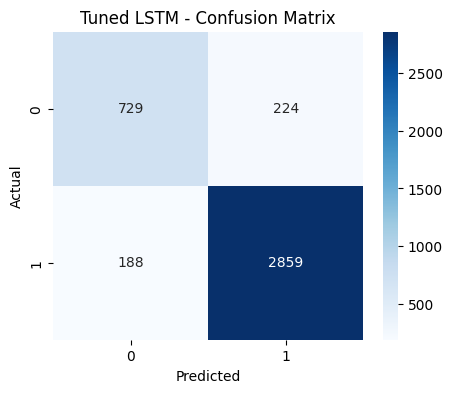

In [40]:
 # Install keras-tuner if not installed
!pip install keras-tuner --quiet

import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam

# Define model-building function
def build_lstm_model(hp):
    model = Sequential()
    model.add(Embedding(input_dim=10000, output_dim=hp.Choice('embedding_dim', [32, 64, 128]), input_length=max_len))
    model.add(Bidirectional(LSTM(
        units=hp.Int('lstm_units', min_value=32, max_value=128, step=32),
        dropout=hp.Float('dropout', 0.2, 0.5, step=0.1)
    )))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Set up tuner
tuner = kt.RandomSearch(
    build_lstm_model,
    objective='val_accuracy',
    max_trials=5,   # try 5 combinations
    executions_per_trial=1,
    directory='lstm_tuner_dir',
    project_name='sentiment_lstm'
)

# Perform search
tuner.search(
    X_train_pad, y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    callbacks=[early_stop]
)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate best model
y_pred_prob = best_model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype('int32').flatten()

print("\n===== Tuned LSTM Evaluation =====")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.title('Tuned LSTM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
